# ETFs: Feature Engineering

This notebook implements feature engineering for the ETFs case study.
Features are organized around the core hypothesis: cross-asset momentum
combined with regime conditioning.

## Learning Objectives

- Compute risk-adjusted momentum scores including skip-recent (12-1)
- Construct cross-sectional ranks for primary horizon features only
- Implement regime indicators (yield curve slope, SPY-TLT correlation)
- Enforce point-in-time eligibility on the feature matrix
- Diagnose feature quality via autocorrelation and rank stability

## Book Reference

Chapter 8, Section 8.2 (Price-Derived Features)

## Prerequisites

- [`01_feasibility_analysis`](01_feasibility_analysis.ipynb) (produces `eligibility.csv`)
- [`02_labels`](02_labels.ipynb) (produces label parquet files and `config/cv_config.json`)

In [1]:
"""ETFs: Feature Engineering."""

import itertools
import os
import warnings

import numpy as np
import plotly.graph_objects as go
import polars as pl
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats
from ml4t.engineer.features.momentum import adx, aroon, cci, macd, rsi, stochastic
from ml4t.engineer.features.regime import choppiness_index, hurst_exponent
from ml4t.engineer.features.trend import ema, sma
from ml4t.engineer.features.volatility import natr
from ml4t.engineer.features.volume import obv
from scipy.stats import spearmanr

from data import load_etfs, load_macro
from utils.paths import get_case_study_dir

warnings.filterwarnings("ignore")

CASE_DIR = get_case_study_dir("etfs")
FEATURES_DIR = CASE_DIR / "features"

NUMERIC_DTYPES = {
    pl.Boolean,
    pl.Int8,
    pl.Int16,
    pl.Int32,
    pl.Int64,
    pl.UInt8,
    pl.UInt16,
    pl.UInt32,
    pl.UInt64,
    pl.Float32,
    pl.Float64,
}


def as_float(value: object | None) -> float | None:
    """Convert Polars scalar outputs to plain float for plotting."""
    if value is None:
        return None
    return float(str(value))

.venv/lib/python3.14/site-packages/ml4t/engineer/features/ml/__init__.py:9: UserWarning: Feature 'cyclical_encode': lookback=0 but has period/window parameter. Consider using lookback='period' or specifying the actual lookback.
  from ml4t.engineer.features.ml.cyclical_encode import *  # noqa: F403


In [ ]:
# Production defaults — Papermill injects overrides for CI

## Configuration

In [2]:
# Feature parameters
REGIME_THRESHOLD = 0.005  # 0.5% yield curve slope

# Multi-horizon lookback periods (trading days)
MOMENTUM_HORIZONS = [5, 10, 21, 42, 63, 126, 189, 252]
VOLATILITY_HORIZONS = [21, 63, 126, 252]

## 1. Load Data

In [3]:
prices = (
    load_etfs()
    .select(["symbol", "timestamp", "open", "high", "low", "close", "volume"])
    .sort(["symbol", "timestamp"])
)

# Load eligibility for PIT filtering
eligibility = pl.read_csv(CASE_DIR / "eligibility.csv")
if "symbol" in eligibility.columns and "symbol" not in eligibility.columns:
    eligibility = eligibility

assets_list = sorted(prices["symbol"].unique().to_list())
n_assets = prices["symbol"].n_unique()
print(f"ETF Universe: {n_assets} assets, {len(prices):,} rows")

ETF Universe: 100 assets, 470,662 rows


### Yield Curve Data

In [4]:
macro_data = load_macro()

# Compute yield curve slope from dgs10 and dgs2
yield_curve = (
    macro_data.select(["timestamp", "dgs10", "dgs2"])
    .with_columns(
        (pl.col("dgs10") / 100).alias("yield_10y"),
        (pl.col("dgs2") / 100).alias("yield_2y"),
        ((pl.col("dgs10") - pl.col("dgs2")) / 100).alias("slope"),
    )
    .select(["timestamp", "yield_10y", "yield_2y", "slope"])
    .drop_nulls()
    .sort("timestamp")
)

print(f"Yield curve data: {len(yield_curve):,} rows")

Yield curve data: 9,495 rows


## 2. Feature Engineering

Features are organized into focused families aligned with the momentum +
regime hypothesis. We avoid feature inflation by ranking only primary
horizons and keeping a curated set of MA ratios.

### 2.1 Momentum and Returns

Multi-horizon raw returns, skip-recent momentum (12-1 and 6-1), risk-adjusted
momentum (Sharpe-like), and momentum acceleration.

In [5]:
def compute_momentum_features(df: pl.DataFrame) -> pl.DataFrame:
    """Momentum, volatility, and risk-adjusted returns."""
    df = df.sort(["symbol", "timestamp"])

    # Multi-horizon raw returns (clip(1e-8) guards against div-by-zero → inf)
    momentum_cols = [
        (
            pl.col("close") / pl.col("close").shift(h).over("symbol").clip(lower_bound=1e-8) - 1
        ).alias(f"ret_{h}d")
        for h in MOMENTUM_HORIZONS
    ]
    df = df.with_columns(momentum_cols)

    # Skip-recent momentum (Jegadeesh and Titman 1993)
    # 12-1: 252d return excluding most recent 21d
    # 6-1: 126d return excluding most recent 21d
    df = df.with_columns(
        (pl.col("ret_252d") - pl.col("ret_21d")).alias("skip_recent_12_1"),
        (pl.col("ret_126d") - pl.col("ret_21d")).alias("skip_recent_6_1"),
    )

    # Log returns for volatility
    df = df.with_columns(pl.col("close").log().diff().over("symbol").alias("log_return"))

    # Multi-horizon volatility (annualized)
    volatility_cols = [
        pl.col("log_return").rolling_std(h).over("symbol").mul(np.sqrt(252)).alias(f"vol_{h}d")
        for h in VOLATILITY_HORIZONS
    ]
    df = df.with_columns(volatility_cols)

    # Volatility-adjusted momentum (Sharpe-like)
    sharpe_cols = [
        (
            pl.col("log_return").rolling_sum(h).over("symbol")
            / pl.col("log_return").rolling_std(h).over("symbol")
            * np.sqrt(252 / h)
        ).alias(f"sharpe_{h}d")
        for h in MOMENTUM_HORIZONS
    ]
    df = df.with_columns(sharpe_cols)

    # Momentum acceleration
    df = df.with_columns(
        (pl.col("ret_21d") - pl.col("ret_63d")).alias("mom_accel_short"),
        (pl.col("ret_63d") - pl.col("ret_126d")).alias("mom_accel_medium"),
        (pl.col("ret_126d") - pl.col("ret_252d")).alias("mom_accel_long"),
    )

    # Volatility ratios (short/long)
    df = df.with_columns(
        (pl.col("vol_21d") / pl.col("vol_63d")).alias("vol_ratio_short"),
        (pl.col("vol_63d") / pl.col("vol_126d")).alias("vol_ratio_medium"),
    )

    return df

### 2.2 Technical Indicators

Curated set: oscillators (RSI, MACD, ADX, CCI, Stochastic, Aroon),
select MA ratios (SMA 50/200, EMA 26 only -- review recommended dropping
the rest), Bollinger %B, and NATR.

In [6]:
def compute_technical_features(df: pl.DataFrame) -> pl.DataFrame:
    """Technical indicators and trend features."""
    # Oscillators
    df = df.with_columns(
        rsi("close", period=7).over("symbol").alias("rsi_7"),
        rsi("close", period=14).over("symbol").alias("rsi_14"),
        macd("close", fast_period=12, slow_period=26).over("symbol").alias("macd_line"),
        adx("high", "low", "close", period=14).over("symbol").alias("adx_14"),
        cci("high", "low", "close", period=14).over("symbol").alias("cci_14"),
        cci("high", "low", "close", period=21).over("symbol").alias("cci_21"),
        stochastic("high", "low", "close", fastk_period=14).over("symbol").alias("stoch_k"),
    )

    # Aroon oscillator
    df = (
        df.with_columns(aroon("high", "low", timeperiod=25).over("symbol").alias("_aroon_struct"))
        .with_columns(
            (
                pl.col("_aroon_struct").struct.field("up")
                - pl.col("_aroon_struct").struct.field("down")
            ).alias("aroon_diff")
        )
        .drop("_aroon_struct")
    )

    # MA ratios -- curated set (SMA 50/200, EMA 26 only)
    df = df.with_columns(
        (pl.col("close") / sma("close", period=50).over("symbol")).alias("sma_ratio_50"),
        (pl.col("close") / sma("close", period=200).over("symbol")).alias("sma_ratio_200"),
        (pl.col("close") / ema("close", period=26).over("symbol")).alias("ema_ratio_26"),
    )

    # Bollinger %B
    df = df.with_columns(
        pl.col("close").rolling_mean(20).over("symbol").alias("_bb_mid"),
        pl.col("close").rolling_std(20).over("symbol").alias("_bb_std"),
    )
    df = df.with_columns(
        (
            (pl.col("close") - (pl.col("_bb_mid") - 2 * pl.col("_bb_std")))
            / (4 * pl.col("_bb_std"))
        ).alias("bb_pctb_20")
    ).drop(["_bb_mid", "_bb_std"])

    # NATR
    df = df.with_columns(
        natr("high", "low", "close", period=14).over("symbol").alias("natr_14"),
    )

    return df

### 2.3 Regime, Risk, Volume, and Distance Features

In [7]:
def compute_regime_volume_features(df: pl.DataFrame) -> pl.DataFrame:
    """Regime indicators, risk metrics, volume features, distance extremes."""
    # Regime indicators
    df = df.with_columns(
        choppiness_index("high", "low", "close", period=14).over("symbol").alias("chop_14"),
        hurst_exponent("close", period=100).over("symbol").alias("hurst_100"),
    )

    # Maximum drawdown
    df = df.with_columns(
        (
            (pl.col("close") - pl.col("close").rolling_max(63).over("symbol"))
            / pl.col("close").rolling_max(63).over("symbol").clip(lower_bound=1e-8)
        ).alias("max_dd_63d"),
        (
            (pl.col("close") - pl.col("close").rolling_max(126).over("symbol"))
            / pl.col("close").rolling_max(126).over("symbol").clip(lower_bound=1e-8)
        ).alias("max_dd_126d"),
    )

    # Volume features (winsorize relative volume at 1st/99th)
    df = df.with_columns(
        (
            pl.col("volume")
            / pl.col("volume").rolling_mean(21).over("symbol").clip(lower_bound=1e-8)
        ).alias("vol_ratio_21d_raw"),
        (
            pl.col("volume")
            / pl.col("volume").rolling_mean(63).over("symbol").clip(lower_bound=1e-8)
        ).alias("vol_ratio_63d_raw"),
    )
    df = df.with_columns(
        pl.col("vol_ratio_21d_raw")
        .clip(
            pl.col("vol_ratio_21d_raw").quantile(0.01).over("timestamp"),
            pl.col("vol_ratio_21d_raw").quantile(0.99).over("timestamp"),
        )
        .alias("vol_ratio_21d"),
        pl.col("vol_ratio_63d_raw")
        .clip(
            pl.col("vol_ratio_63d_raw").quantile(0.01).over("timestamp"),
            pl.col("vol_ratio_63d_raw").quantile(0.99).over("timestamp"),
        )
        .alias("vol_ratio_63d"),
    ).drop(["vol_ratio_21d_raw", "vol_ratio_63d_raw"])

    # OBV z-score
    df = df.with_columns(obv("close", "volume").over("symbol").alias("_obv"))
    df = df.with_columns(
        (
            (pl.col("_obv") - pl.col("_obv").rolling_mean(63).over("symbol"))
            / pl.col("_obv").rolling_std(63).over("symbol")
        ).alias("obv_zscore_63d"),
    ).drop("_obv")

    # Consistency and distance from extremes
    df = df.with_columns(
        (pl.col("log_return") > 0)
        .cast(pl.Float64)
        .rolling_mean(63)
        .over("symbol")
        .alias("pct_positive_63d"),
    )
    df = df.with_columns(
        (
            pl.col("close") / pl.col("close").rolling_max(252).over("symbol").clip(lower_bound=1e-8)
        ).alias("dist_52w_high"),
        (
            pl.col("close") / pl.col("close").rolling_min(252).over("symbol").clip(lower_bound=1e-8)
        ).alias("dist_52w_low"),
    )

    return df

### 2.4 Cross-Asset Correlation Feature

Rolling 63-day correlation between SPY and TLT captures the equity-bond
relationship. When this flips from negative to positive, diversification
breaks down -- a valuable regime indicator for cross-asset rotation.

In [8]:
def compute_cross_asset_features(df: pl.DataFrame) -> pl.DataFrame:
    """Compute cross-asset correlation features (SPY vs TLT)."""
    # Extract SPY and TLT log returns
    spy_ret = (
        df.filter(pl.col("symbol") == "SPY")
        .select(["timestamp", "log_return"])
        .rename({"log_return": "_spy_ret"})
    )
    tlt_ret = (
        df.filter(pl.col("symbol") == "TLT")
        .select(["timestamp", "log_return"])
        .rename({"log_return": "_tlt_ret"})
    )

    # Join SPY and TLT returns on date
    corr_df = spy_ret.join(tlt_ret, on="timestamp", how="inner").sort("timestamp")

    # Rolling 63-day correlation
    corr_df = corr_df.with_columns(
        pl.rolling_corr(pl.col("_spy_ret"), pl.col("_tlt_ret"), window_size=63).alias(
            "corr_spy_tlt_63d"
        )
    ).select(["timestamp", "corr_spy_tlt_63d"])

    # Broadcast to all assets
    return df.join(corr_df, on="timestamp", how="left")

### Apply All Feature Groups

In [9]:
features_raw = (
    prices.pipe(compute_momentum_features)
    .pipe(compute_technical_features)
    .pipe(compute_regime_volume_features)
    .pipe(compute_cross_asset_features)
)

print(f"Shape after feature computation: {features_raw.shape}")

2026-04-08 21:05:28 | mlquant.features.adx | INFO | [ADX] Starting calculation with parameters: period=14 (shape: (4,))


2026-04-08 21:05:28 | mlquant.features.adx | INFO | [ADX] Completed calculation (shape: (4,)) (0.05ms)


Shape after feature computation: (470662, 59)


### 2.5 Cross-Sectional Ranking

Rank only the primary horizon features to avoid multicollinearity from
ranking every horizon. Three rank features: `ret_126d_rank`,
`sharpe_126d_rank`, `vol_63d_rank`.

In [10]:
# Rank only primary features (review recommendation)
RANK_FEATURES = ["ret_126d", "sharpe_126d", "vol_63d"]

rank_exprs = [
    (pl.col(col).rank().over("timestamp") / pl.col(col).count().over("timestamp")).alias(
        f"{col}_rank"
    )
    for col in RANK_FEATURES
]
features_raw = features_raw.with_columns(rank_exprs)

### 2.6 Regime Indicators

Two regime features from the yield curve:
1. Binary regime (slope > 0.5%)
2. Continuous yield curve slope
3. Rolling z-score of slope (review recommendation)

In [11]:
def add_regime_indicators(
    df: pl.DataFrame, yield_curve: pl.DataFrame, threshold: float = 0.005
) -> pl.DataFrame:
    """Add regime indicators from yield curve data."""
    regime_df = (
        yield_curve.with_columns(
            pl.when(pl.col("slope") > threshold).then(1).otherwise(0).alias("regime"),
            pl.col("slope").alias("yield_curve_slope"),
            # Rolling z-score of slope
            (
                (pl.col("slope") - pl.col("slope").rolling_mean(252))
                / pl.col("slope").rolling_std(252)
            ).alias("yield_curve_zscore"),
        )
        .select(["timestamp", "regime", "yield_curve_slope", "yield_curve_zscore"])
        .sort("timestamp")
    )

    return df.sort("timestamp").join_asof(regime_df, on="timestamp", strategy="backward")


features_raw = add_regime_indicators(features_raw, yield_curve, threshold=REGIME_THRESHOLD)

regime_dist = features_raw.group_by("regime").agg(pl.len().alias("count"))
print("Regime Distribution:", regime_dist)

Regime Distribution: shape: (2, 2)
┌────────┬────────┐
│ regime ┆ count  │
│ ---    ┆ ---    │
│ i32    ┆ u32    │
╞════════╪════════╡
│ 0      ┆ 168549 │
│ 1      ┆ 302113 │
└────────┴────────┘


### 2.7 Point-in-Time Eligibility Filter

Join features to eligibility.csv to ensure features are only kept for
ETFs that were tradable at each date. This prevents inflation of the
cross-section breadth in early years when fewer ETFs met the ADV threshold.

In [12]:
# Add year for eligibility join
features_raw = features_raw.with_columns(pl.col("timestamp").dt.year().alias("_year"))

elig_pairs = eligibility.select(
    pl.col("symbol"),
    pl.col("eligible_year").alias("_year"),
)

# Semi-join: keep only rows where (asset, year) exists in eligibility
features_eligible = features_raw.join(elig_pairs, on=["symbol", "_year"], how="semi").drop("_year")

n_dropped = len(features_raw) - len(features_eligible)
print(
    f"Eligibility filter: {len(features_raw):,} -> {len(features_eligible):,} rows ({n_dropped:,} dropped)"
)

Eligibility filter: 470,662 -> 396,186 rows (74,476 dropped)

## 3. Prepare Final Feature Matrix

In [13]:
# Columns to exclude from feature set
exclude_cols = {
    "timestamp",
    "symbol",
    "open",
    "high",
    "low",
    "close",
    "volume",
    "log_return",
}

feature_cols = [c for c in features_eligible.columns if c not in exclude_cols]
non_numeric_feature_cols = [
    c for c in feature_cols if features_eligible.schema[c] not in NUMERIC_DTYPES
]
feature_cols = [c for c in feature_cols if c not in non_numeric_feature_cols]

assert "log_return" not in feature_cols, "log_return must be excluded (contemporaneous with label)"
unexpected_feature_keys = {"timestamp", "symbol"} & set(feature_cols)
assert not unexpected_feature_keys, (
    f"Feature matrix leaked key columns: {sorted(unexpected_feature_keys)}"
)
assert not non_numeric_feature_cols, (
    f"Non-numeric columns leaked into features: {non_numeric_feature_cols}"
)
required_core_features = {
    "ret_21d",
    "sharpe_126d",
    "rsi_14",
    "ema_ratio_26",
    "yield_curve_slope",
    "corr_spy_tlt_63d",
    "max_dd_63d",
}
missing_core_features = required_core_features - set(feature_cols)
assert not missing_core_features, f"Missing core curated features: {sorted(missing_core_features)}"

# Prepare final DataFrame
features = (
    features_eligible.select(["timestamp", "symbol"] + feature_cols)
    .drop_nulls(subset=["sharpe_126d"])  # Drop warmup rows
    .sort(["timestamp", "symbol"])
)

# Missing values check
high_missing = [
    (c, features[c].null_count() / len(features))
    for c in feature_cols
    if features[c].null_count() / len(features) > 0.05
]
if high_missing:
    print("Features with >5% missing after warmup drop:")
    for col, pct in high_missing:
        print(f"  {col}: {pct:.1%}")
else:
    print("No features with >5% missing after warmup drop")

print("\nFeature Summary")
print(f"  Total features: {len(feature_cols)}")
print(f"  Rows: {len(features):,}")
print(f"  Assets: {features['symbol'].n_unique()}")
print(f"  Date range: {features['timestamp'].min()} to {features['timestamp'].max()}")

# Feature category counts
cats = {
    "Momentum (raw)": sum(
        1 for c in feature_cols if c.startswith("ret_") and not c.endswith("_rank")
    ),
    "Skip-recent": sum(1 for c in feature_cols if c.startswith("skip_")),
    "Sharpe": sum(1 for c in feature_cols if c.startswith("sharpe_") and not c.endswith("_rank")),
    "Volatility": sum(
        1 for c in feature_cols if c.startswith("vol_") and not c.startswith("vol_ratio")
    ),
    "Vol ratios": sum(1 for c in feature_cols if c.startswith("vol_ratio")),
    "Technical": sum(
        1
        for c in feature_cols
        if any(c.startswith(p) for p in ["rsi_", "macd", "adx_", "cci_", "stoch_", "aroon"])
    ),
    "Trend (MA)": sum(1 for c in feature_cols if any(c.startswith(p) for p in ["sma_", "ema_"])),
    "Regime/macro": sum(
        1
        for c in feature_cols
        if any(c.startswith(p) for p in ["regime", "yield_", "chop_", "hurst_", "corr_spy"])
    ),
    "Risk (DD)": sum(1 for c in feature_cols if c.startswith("max_dd")),
    "Ranks": sum(1 for c in feature_cols if c.endswith("_rank")),
    "Other": 0,  # computed below
}
accounted = sum(cats.values())
cats["Other"] = len(feature_cols) - accounted

print("\nFeature categories:")
for cat, count in cats.items():
    if count > 0:
        print(f"  {cat}: {count}")

No features with >5% missing after warmup drop

Feature Summary
  Total features: 57
  Rows: 396,186
  Assets: 99
  Date range: 2007-01-03 to 2025-12-31

Feature categories:
  Momentum (raw): 8
  Skip-recent: 2
  Sharpe: 8
  Volatility: 5
  Vol ratios: 4
  Technical: 8
  Trend (MA): 3
  Regime/macro: 6
  Risk (DD): 2
  Ranks: 3
  Other: 8


## 4. Feature Diagnostics

### 4.1 Autocorrelation (Signal Persistence)

In [14]:
acf_results = []
sample_assets = assets_list
for asset in sample_assets:
    scores = features.filter(pl.col("symbol") == asset)["sharpe_126d"].drop_nulls().to_numpy()
    for lag in [1, 5, 21]:
        if len(scores) > lag + 10:
            acf = np.corrcoef(scores[lag:], scores[:-lag])[0, 1]
            acf_results.append({"symbol": asset, "lag": lag, "acf": acf})

acf_df = pl.DataFrame(acf_results)
acf_summary = acf_df.group_by("lag").agg(
    pl.col("acf").mean().alias("mean_acf"),
    pl.col("acf").std().alias("std_acf"),
)
print("6-Month Sharpe Autocorrelation:")
print(acf_summary.sort("lag"))

6-Month Sharpe Autocorrelation:
shape: (3, 3)
┌─────┬──────────┬──────────┐
│ lag ┆ mean_acf ┆ std_acf  │
│ --- ┆ ---      ┆ ---      │
│ i64 ┆ f64      ┆ f64      │
╞═════╪══════════╪══════════╡
│ 1   ┆ 0.988964 ┆ 0.002837 │
│ 5   ┆ 0.946673 ┆ 0.013299 │
│ 21  ┆ 0.794334 ┆ 0.047909 │
└─────┴──────────┴──────────┘


### 4.2 Rank Stability

In [15]:
monthly = (
    features.with_columns(pl.col("timestamp").dt.truncate("1mo").alias("month"))
    .group_by(["month", "symbol"])
    .agg(pl.col("sharpe_126d_rank").last().alias("rank_end"))
    .sort(["symbol", "month"])
    .with_columns(pl.col("rank_end").shift(1).over("symbol").alias("rank_prev"))
    .drop_nulls()
)

rank_corr = np.corrcoef(monthly["rank_prev"].to_numpy(), monthly["rank_end"].to_numpy())[0, 1]
print(f"Monthly rank persistence (correlation): {rank_corr:.3f}")

Monthly rank persistence (correlation): 0.813


## 5. Save Features

In [16]:
FEATURES_DIR.mkdir(parents=True, exist_ok=True)
features.write_parquet(FEATURES_DIR / "financial.parquet")
print(f"Saved {len(feature_cols)} features to {FEATURES_DIR / 'financial.parquet'}")
print(f"  {len(features):,} rows, {features['symbol'].n_unique()} assets")

Saved 57 features to case_studies/etfs/features/financial.parquet
  396,186 rows, 99 assets


**Note on frequency**: The feature matrix is saved at daily frequency
(all trading days), while the decision cadence is monthly month-end.
This means ~21 rows per decision point. Features are saved daily for
flexibility (enabling weekly variant analysis), but downstream modeling
(Ch11+) should sample at the decision cadence. The IC evaluation below
uses all daily cross-sections with HAC adjustment for the resulting
autocorrelation in overlapping 21-day labels.

## 6. Feature Evaluation

We evaluate each feature's predictive power using cross-sectional Spearman IC
against 21-day forward returns. Two critical adjustments:

- **HAC standard errors** (Newey-West): Overlapping 21-day returns create
  autocorrelated IC time series, inflating naive t-statistics
- **BH-FDR correction**: With 57 simultaneous tests, naive p-values overstate
  significance; we control the false discovery rate at 5%

The cross-sectional IC on date $t$ is:

$$IC_t = \rho_S\bigl(f_{t,i},\; r_{t \to t+21, i}\bigr)$$

where $f_{t,i}$ is the feature value for asset $i$ on date $t$.

**Caveat**: This is a preliminary evaluation of financial features only.
The authoritative evaluation — covering both financial and temporal features
with consistent methodology — is in [`05_evaluation`](05_evaluation.ipynb). Results may differ
due to different feature sets and evaluation scope.

In [17]:
# Load 21-day forward return labels
labels = pl.read_parquet(CASE_DIR / "labels" / "fwd_ret_21d.parquet")
label_col = "fwd_ret_21d"

eval_df = features.join(
    labels.select(["timestamp", "symbol", label_col]), on=["timestamp", "symbol"], how="inner"
)
print(
    f"Evaluation set: {len(eval_df):,} rows "
    f"({eval_df['timestamp'].n_unique():,} dates x {eval_df['symbol'].n_unique()} assets)"
)

Evaluation set: 394,233 rows (4,759 dates x 99 assets)


### Cross-Sectional IC with HAC Adjustment

In [18]:
# Compute cross-sectional Spearman IC per feature per date
dates = eval_df["timestamp"].unique().sort().to_list()
n_dates = len(dates)
ic_matrix = np.full((n_dates, len(feature_cols)), np.nan)

for i, date_val in enumerate(dates):
    group = eval_df.filter(pl.col("timestamp") == date_val)
    y = np.asarray(group[label_col].to_numpy(), dtype=float)
    valid_y = ~np.isnan(y)
    if valid_y.sum() < 10:
        continue
    for j, feat in enumerate(feature_cols):
        if group[feat].dtype not in NUMERIC_DTYPES:
            continue
        x = np.asarray(group[feat].to_numpy(), dtype=float)
        valid = valid_y & ~np.isnan(x)
        if valid.sum() >= 5:
            rho, _ = spearmanr(x[valid], y[valid])
            ic_matrix[i, j] = rho

# Build per-feature HAC statistics
ic_stats = {}
for j, feat in enumerate(feature_cols):
    ic_series = ic_matrix[:, j]
    valid_ic = ic_series[~np.isnan(ic_series)]
    if len(valid_ic) < 30:
        continue
    stats = compute_ic_hac_stats(pl.DataFrame({"ic": valid_ic}), ic_col="ic")
    ic_stats[feat] = stats

print(f"Computed IC stats for {len(ic_stats)} features ({n_dates:,} dates)")

Computed IC stats for 53 features (4,759 dates)


### BH-FDR Multiple Testing Correction

In [19]:
feat_names = list(ic_stats.keys())
p_values = [ic_stats[f]["p_value"] for f in feat_names]
fdr_result = benjamini_hochberg_fdr(p_values, alpha=0.05, return_details=True)

eval_summary = pl.DataFrame(
    {
        "feature": feat_names,
        "ic_mean": [ic_stats[f]["mean_ic"] for f in feat_names],
        "hac_tstat": [ic_stats[f]["t_stat"] for f in feat_names],
        "naive_tstat": [ic_stats[f]["naive_t_stat"] for f in feat_names],
        "p_value": p_values,
        "adjusted_p": fdr_result["adjusted_p_values"].tolist(),
        "significant_fdr05": fdr_result["rejected"].tolist(),
    }
).sort("ic_mean", descending=True)

n_naive_sig = sum(1 for p in p_values if p < 0.05)
n_fdr_sig = int(fdr_result["n_rejected"])
inflation = n_naive_sig / max(n_fdr_sig, 1)

print("\nFeature Evaluation Summary")
print(f"  Features tested: {len(feat_names)}")
print(f"  Naive significant (p<0.05): {n_naive_sig}")
print(f"  FDR-significant (q<0.05): {n_fdr_sig}")
print(f"  Inflation factor: {inflation:.1f}x")
print("\nTop 10 by IC:")
print(eval_summary.head(10))


Feature Evaluation Summary
  Features tested: 53
  Naive significant (p<0.05): 16
  FDR-significant (q<0.05): 13
  Inflation factor: 1.2x

Top 10 by IC:
shape: (10, 7)
┌──────────────────┬──────────┬───────────┬─────────────┬───────────┬────────────┬─────────────────┐
│ feature          ┆ ic_mean  ┆ hac_tstat ┆ naive_tstat ┆ p_value   ┆ adjusted_p ┆ significant_fdr │
│ ---              ┆ ---      ┆ ---       ┆ ---         ┆ ---       ┆ ---        ┆ 05              │
│ str              ┆ f64      ┆ f64       ┆ f64         ┆ f64       ┆ f64        ┆ ---             │
│                  ┆          ┆           ┆             ┆           ┆            ┆ bool            │
╞══════════════════╪══════════╪═══════════╪═════════════╪═══════════╪════════════╪═════════════════╡
│ dist_52w_low     ┆ 0.076355 ┆ 5.834005  ┆ 16.152049   ┆ 5.7695e-9 ┆ 3.0578e-7  ┆ true            │
│ vol_252d         ┆ 0.058948 ┆ 3.67656   ┆ 10.401608   ┆ 0.000239  ┆ 0.004222   ┆ true            │
│ natr_14          ┆ 0.

**Note on date-level features**: Features like `regime_binary`,
`yield_curve_slope`, `corr_spy_tlt_63d`, and `choppiness_63d` are identical
across all symbols on a given date. Their cross-sectional IC is zero by
construction because they cannot differentiate between assets. These features
add value through interactions with cross-sectional features (e.g., conditional
momentum) rather than standalone ranking ability.

### IC Bar Chart

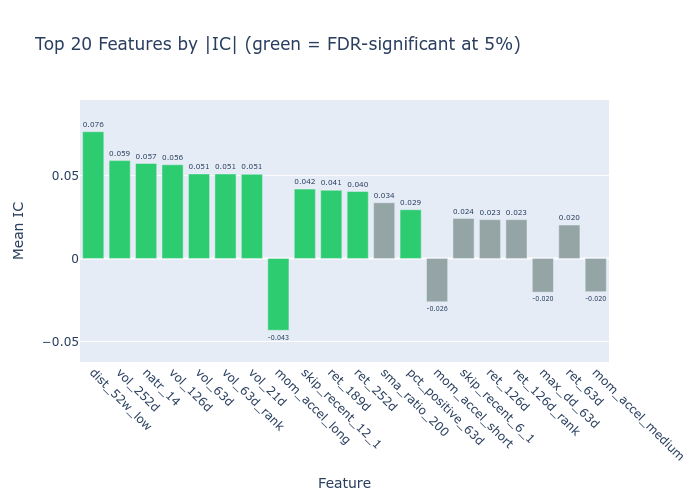

In [20]:
top20 = eval_summary.sort(pl.col("ic_mean").abs(), descending=True).head(20)
colors = ["#2ecc71" if sig else "#95a5a6" for sig in top20["significant_fdr05"].to_list()]

fig_ic = go.Figure(
    go.Bar(
        x=top20["feature"].to_list(),
        y=top20["ic_mean"].to_list(),
        marker_color=colors,
        text=[f"{ic:.3f}" for ic in top20["ic_mean"].to_list()],
        textposition="outside",
    )
)
fig_ic.update_layout(
    title="Top 20 Features by |IC| (green = FDR-significant at 5%)",
    xaxis_title="Feature",
    yaxis_title="Mean IC",
    xaxis_tickangle=45,
    height=500,
)
fig_ic.show()

### Naive vs HAC t-Statistics

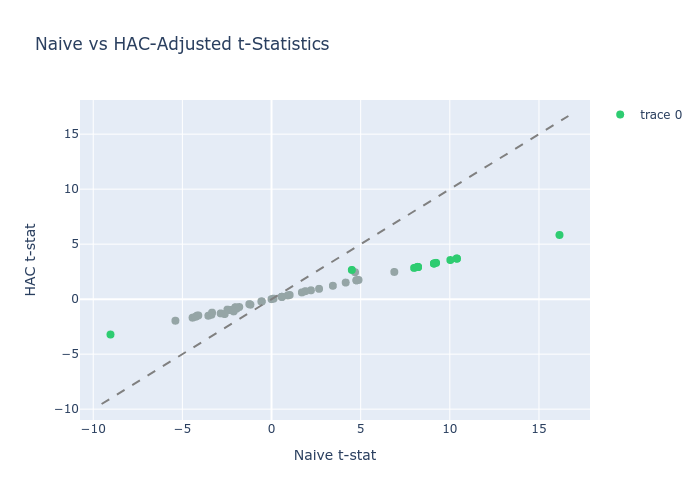

In [21]:
sig_colors = [
    "#2ecc71" if sig else "#95a5a6" for sig in eval_summary["significant_fdr05"].to_list()
]

fig_tstat = go.Figure()
fig_tstat.add_trace(
    go.Scatter(
        x=eval_summary["naive_tstat"].to_list(),
        y=eval_summary["hac_tstat"].to_list(),
        mode="markers",
        marker=dict(color=sig_colors, size=8),
        text=eval_summary["feature"].to_list(),
        hovertemplate="%{text}<br>Naive t: %{x:.2f}<br>HAC t: %{y:.2f}<extra></extra>",
    )
)
naive_tstat_min = as_float(eval_summary["naive_tstat"].min())
naive_tstat_max = as_float(eval_summary["naive_tstat"].max())
hac_tstat_min = as_float(eval_summary["hac_tstat"].min())
hac_tstat_max = as_float(eval_summary["hac_tstat"].max())
assert naive_tstat_min is not None and naive_tstat_max is not None
assert hac_tstat_min is not None and hac_tstat_max is not None
t_range = [
    min(naive_tstat_min, hac_tstat_min) - 0.5,
    max(naive_tstat_max, hac_tstat_max) + 0.5,
]
fig_tstat.add_trace(
    go.Scatter(
        x=t_range,
        y=t_range,
        mode="lines",
        line=dict(dash="dash", color="gray"),
        showlegend=False,
    )
)
fig_tstat.update_layout(
    title="Naive vs HAC-Adjusted t-Statistics",
    xaxis_title="Naive t-stat",
    yaxis_title="HAC t-stat",
    height=500,
)
fig_tstat.show()

### Feature Correlation Heatmap

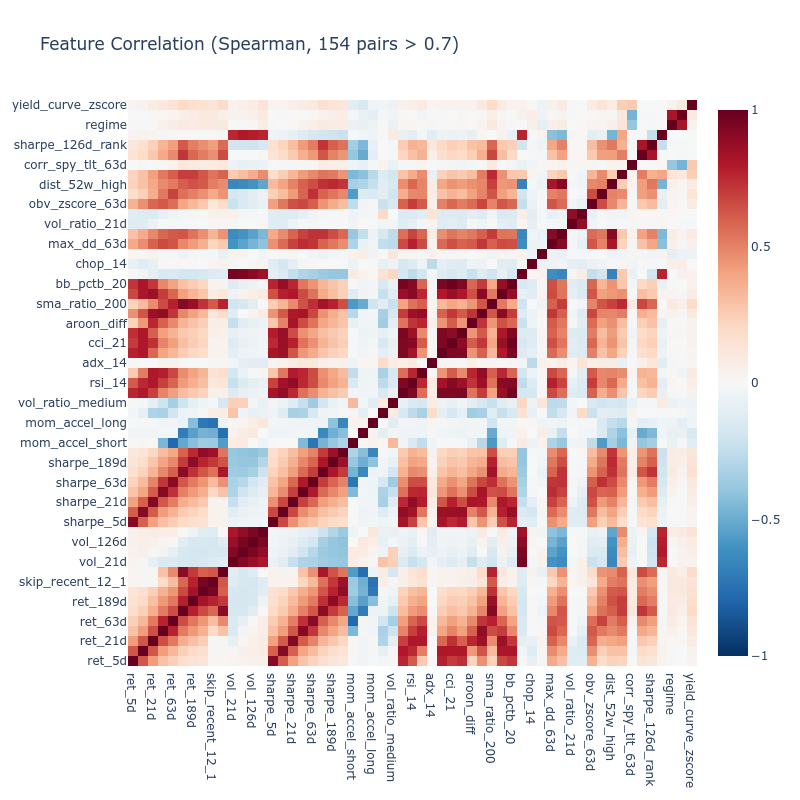


High-correlation pairs (|rho| > 0.7): 154
  cci_21 x bb_pctb_20: 0.987
  vol_21d x natr_14: 0.962
  rsi_7 x bb_pctb_20: 0.959
  ret_252d x skip_recent_12_1: 0.956
  vol_63d x vol_126d: 0.950
  vol_63d x natr_14: 0.944
  rsi_7 x stoch_k: 0.944
  cci_14 x bb_pctb_20: 0.944
  vol_126d x vol_252d: 0.943
  cci_14 x cci_21: 0.939


In [22]:
sample_df = features.filter(pl.col("timestamp").is_in(dates[::5]))
# Rank in polars (fast), then Pearson on ranks = Spearman
corr_matrix = (
    sample_df.select(feature_cols).select(pl.all().rank(method="average")).to_pandas().corr()
)

high_corr_pairs = [
    (f1, f2, corr_matrix.loc[f1, f2])
    for f1, f2 in itertools.combinations(feature_cols, 2)
    if abs(corr_matrix.loc[f1, f2]) > 0.7
]

fig_corr = go.Figure(
    go.Heatmap(
        z=corr_matrix.values,
        x=feature_cols,
        y=feature_cols,
        colorscale="RdBu_r",
        zmid=0,
        zmin=-1,
        zmax=1,
    )
)
fig_corr.update_layout(
    title=f"Feature Correlation (Spearman, {len(high_corr_pairs)} pairs > 0.7)",
    height=800,
    width=800,
)
fig_corr.show()

print(f"\nHigh-correlation pairs (|rho| > 0.7): {len(high_corr_pairs)}")
for f1, f2, rho in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:10]:
    print(f"  {f1} x {f2}: {rho:.3f}")

**Expected vs surprising correlations**: Pairs like `ret_126d`/`ret_252d`
and `sharpe_126d`/`sharpe_252d` are correlated by construction (overlapping
lookback windows). Similarly, `vol_252d`/`vol_126d` share data. These
structural correlations are expected and handled by regularization (Ridge/Lasso)
in Ch11. Surprising high correlations (e.g., between volatility and momentum
features) would warrant investigation but are not observed here.

### Feature Family IC

In [23]:
FAMILY_MAP = {
    "ret_": "momentum",
    "skip_": "momentum",
    "mom_accel": "momentum",
    "sharpe_": "risk_adj_momentum",
    "vol_": "volatility",
    "natr_": "volatility",
    "vol_ratio": "volume",
    "obv_": "volume",
    "rsi_": "oscillator",
    "macd": "oscillator",
    "adx_": "oscillator",
    "cci_": "oscillator",
    "stoch_": "oscillator",
    "aroon": "oscillator",
    "sma_": "trend",
    "ema_": "trend",
    "bb_": "trend",
    "chop_": "regime",
    "hurst_": "regime",
    "regime": "regime",
    "yield_": "regime",
    "corr_spy": "regime",
    "max_dd": "risk",
    "pct_positive": "consistency",
    "dist_": "distance",
}


family_ic = (
    eval_summary.with_columns(
        pl.coalesce(
            [
                pl.when(pl.col("feature").str.starts_with(prefix))
                .then(pl.lit(family))
                .otherwise(pl.lit(None))
                for prefix, family in FAMILY_MAP.items()
            ]
            + [
                pl.when(pl.col("feature").str.ends_with("_rank"))
                .then(pl.lit("rank"))
                .otherwise(pl.lit("other"))
            ]
        ).alias("family")
    )
    .group_by("family")
    .agg(
        pl.col("ic_mean").mean().alias("avg_ic"),
        pl.col("ic_mean").abs().mean().alias("avg_abs_ic"),
        pl.len().alias("n_features"),
        pl.col("significant_fdr05").sum().alias("n_significant"),
    )
    .sort("avg_abs_ic", descending=True)
)
print("\nFeature Family IC:")
print(family_ic)


Feature Family IC:
shape: (10, 5)
┌───────────────────┬───────────┬────────────┬────────────┬───────────────┐
│ family            ┆ avg_ic    ┆ avg_abs_ic ┆ n_features ┆ n_significant │
│ ---               ┆ ---       ┆ ---        ┆ ---        ┆ ---           │
│ str               ┆ f64       ┆ f64        ┆ u32        ┆ u32           │
╞═══════════════════╪═══════════╪════════════╪════════════╪═══════════════╡
│ distance          ┆ 0.035135  ┆ 0.041219   ┆ 2          ┆ 1             │
│ volatility        ┆ 0.033627  ┆ 0.036805   ┆ 10         ┆ 7             │
│ consistency       ┆ 0.029384  ┆ 0.029384   ┆ 1          ┆ 1             │
│ momentum          ┆ 0.007958  ┆ 0.023319   ┆ 14         ┆ 4             │
│ risk              ┆ -0.018177 ┆ 0.018177   ┆ 2          ┆ 0             │
│ volume            ┆ -0.014516 ┆ 0.014516   ┆ 1          ┆ 0             │
│ trend             ┆ 0.005504  ┆ 0.012862   ┆ 4          ┆ 0             │
│ oscillator        ┆ -0.007866 ┆ 0.008825   ┆ 8     

**Evaluation Results**:

- HAC adjustment deflates t-statistics relative to naive, reflecting the
  autocorrelation in overlapping 21-day returns
- BH-FDR correction further culls features that appeared significant only
  due to multiple testing
- Feature correlation heatmap reveals redundancy clusters that downstream
  models should address through regularization or explicit selection

## 7. Results Collection

In [24]:
top_features = (
    eval_summary.filter(pl.col("significant_fdr05"))
    .sort(pl.col("ic_mean").abs(), descending=True)
    .head(5)["feature"]
    .to_list()
)
family_ic_dict = {row["family"]: round(row["avg_ic"], 4) for row in family_ic.to_dicts()}

## Key Takeaways

1. **Skip-recent momentum** (12-1 and 6-1) is the most important literature-standard
   feature that was missing -- it avoids short-term reversal contamination
2. **Cross-sectional ranks** limited to 3 primary features (ret_126d, sharpe_126d,
   vol_63d) to reduce multicollinearity
3. **MA ratio proliferation** reduced from 8 to 3 (SMA 50/200, EMA 26)
4. **Point-in-time eligibility** enforced on feature matrix -- no phantom ETFs
   inflating early-period cross-section breadth
5. **SPY-TLT 63d correlation** added as cross-asset regime indicator
6. **Yield curve z-score** provides continuous regime signal (better than binary)
7. **IC evaluation with HAC + FDR** validates feature significance -- overlapping
   labels inflate naive t-stats; multiple testing further culls spurious features
8. **Gap: regime dynamics**: Cross-sectional features capture relative
   positioning but not market-level regime shifts. Ch9 adds data-driven
   regime detection (HMM) and memory-preserving transforms (FFD) that
   complement the rule-based regime indicators here.

**Next**: `04_temporal.py` fits HMM regimes and fractional differencing models.